# Main Optotagging Analysis Notebook


Main notebook for analysis of cell-type distribution throughout the entire Allen Institute Visual Behavior Neuropixels Dataset. 

Uses imports from the visb_analysis package, which reuses code from the Allen Institute Visual Behavior Optotagging Tutorial notebook.

### Loads data from `results/` folder

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import yaml

from visb_analysis.plots import (
    plot_units_per_session,
    plot_population_psth,
    plot_psth_heatmaps,
    plot_labeled_cells_by_region,
    plot_cre_density_by_region,
)

In [13]:
GENOTYPES = ["Vip", "Sst", "WT"]

In [14]:
configs = {}
for gt in GENOTYPES:
    cfg_path = Path("../configs") / f"{gt}.yaml"
    with cfg_path.open("r") as f:
        configs[gt] = yaml.safe_load(f)

In [15]:
data_by_genotype = {}
for gt, config in configs.items():
    results_dir = Path(config["results_dir"]) / gt
    all_psths, all_unit_ids, all_units_meta = [], [], []
    time_bins = None
    for npz_path in sorted(results_dir.glob("*.npz")):
        session_id = int(npz_path.stem)
        data = np.load(npz_path)
        meta = pd.read_csv(results_dir / f"{session_id}_units.csv", index_col=0)
        all_psths.append(data["psth_array"])
        all_unit_ids.append(data["unit_ids"])
        all_units_meta.append(meta)
        if time_bins is None:
            time_bins = data["time_bins"]
    if not all_psths:
        raise FileNotFoundError(f"No .npz files found in {results_dir}")
    data_by_genotype[gt] = {
        "all_psths":      all_psths,
        "all_units_meta": all_units_meta,
        "time_bins":      time_bins,
    }

In [16]:
derived = {}
for gt, d in data_by_genotype.items():
    psth_trial_avg = np.concatenate(d["all_psths"], axis=0)
    meta_all = pd.concat(d["all_units_meta"])
    meta_all["optotagged"] = meta_all["optotagged"].fillna(False).astype(bool)
    opto_mask = meta_all["optotagged"].values
    derived[gt] = {
        "psth_trial_avg":  psth_trial_avg,
        "meta_all":        meta_all,
        "opto_mask":       opto_mask,
        "psth_opto":       psth_trial_avg[opto_mask],
        "psth_non_opto":   psth_trial_avg[~opto_mask],
        "time_bins":       d["time_bins"],
        "all_units_meta":  d["all_units_meta"],
    }

### Analyze & Visualize results

In [17]:
col_w = 14
print(f"{'':30}" + "".join(f"{gt:>{col_w}}" for gt in GENOTYPES))
print("-" * (30 + col_w * len(GENOTYPES)))

stats = {}
for gt, d in derived.items():
    om    = d["opto_mask"]
    metas = d["all_units_meta"]
    sess_pos = [m["optotagged"].fillna(False).astype(bool).sum() for m in metas]
    stats[gt] = {
        "sessions":       len(metas),
        "total":          len(om),
        "labeled":        int(om.sum()),
        "unlabeled":      int((~om).sum()),
        "pct":            100 * om.mean(),
        "mean_per_sess":  np.mean(sess_pos),
        "std_per_sess":   np.std(sess_pos),
    }

def _row(label, fn):
    print(f"{label:30}" + "".join(f"{fn(stats[gt]):>{col_w}}" for gt in GENOTYPES))

_row("Sessions",           lambda s: str(s["sessions"]))
_row("Total units",        lambda s: str(s["total"]))
_row("Labeled (Cre+)",     lambda s: f"{s['labeled']} ({s['pct']:.1f}%)")
_row("Unlabeled",          lambda s: str(s["unlabeled"]))
_row("Mean Cre+/session",  lambda s: f"{s['mean_per_sess']:.1f}")
_row("Std Cre+/session",   lambda s: f"{s['std_per_sess']:.1f}")

                                         Vip           Sst            WT
------------------------------------------------------------------------
Sessions                                  11            21            20
Total units                            14398         25969         24657
Labeled (Cre+)                     34 (0.2%)   1053 (4.1%)      4 (0.0%)
Unlabeled                              14364         24916         24653
Mean Cre+/session                        3.1          50.1           0.2
Std Cre+/session                         2.6          24.6           0.4


### Population average PSTH

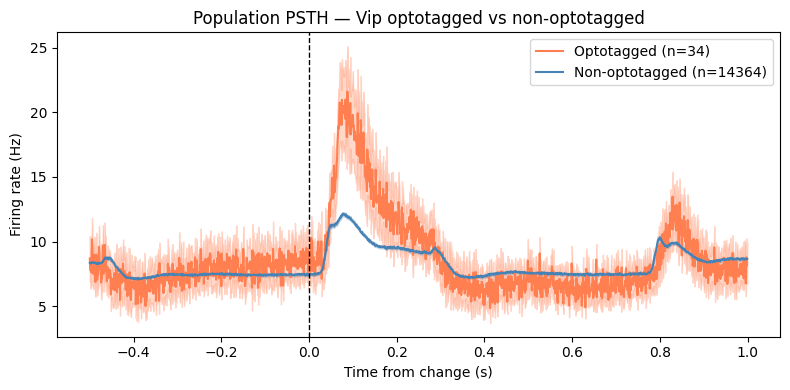

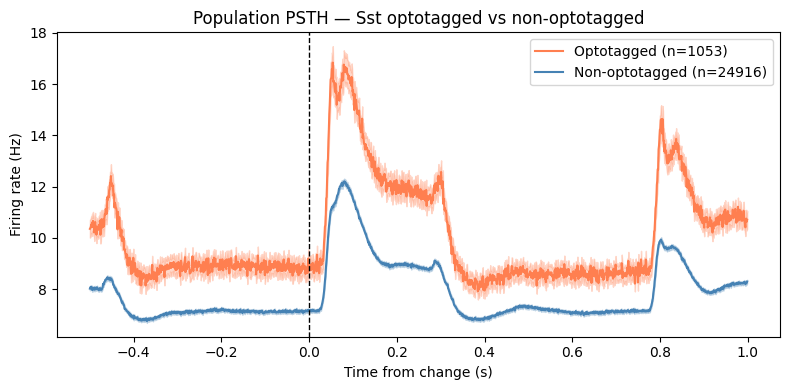

In [7]:
for gt, d in derived.items():
    fig = plot_population_psth(
        d["psth_opto"], d["psth_non_opto"], d["time_bins"],
        title=f'Population PSTH — {gt} optotagged vs non-optotagged',
    )

### Unit heatmap (sorted by response magnitude)

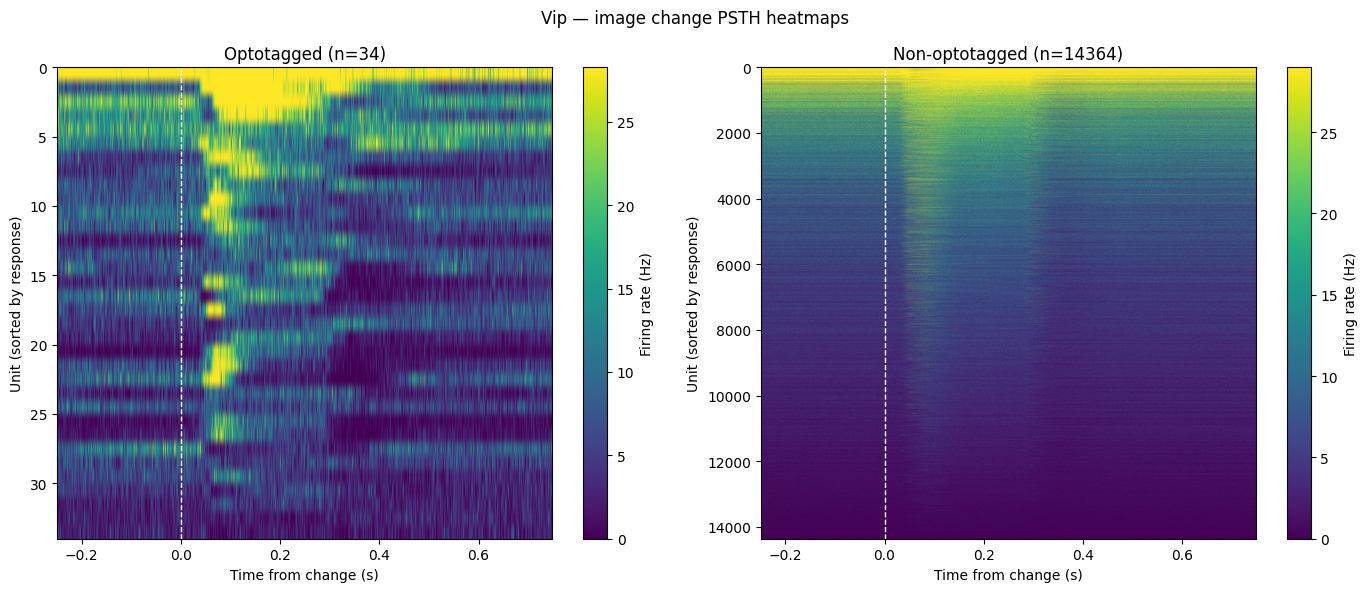

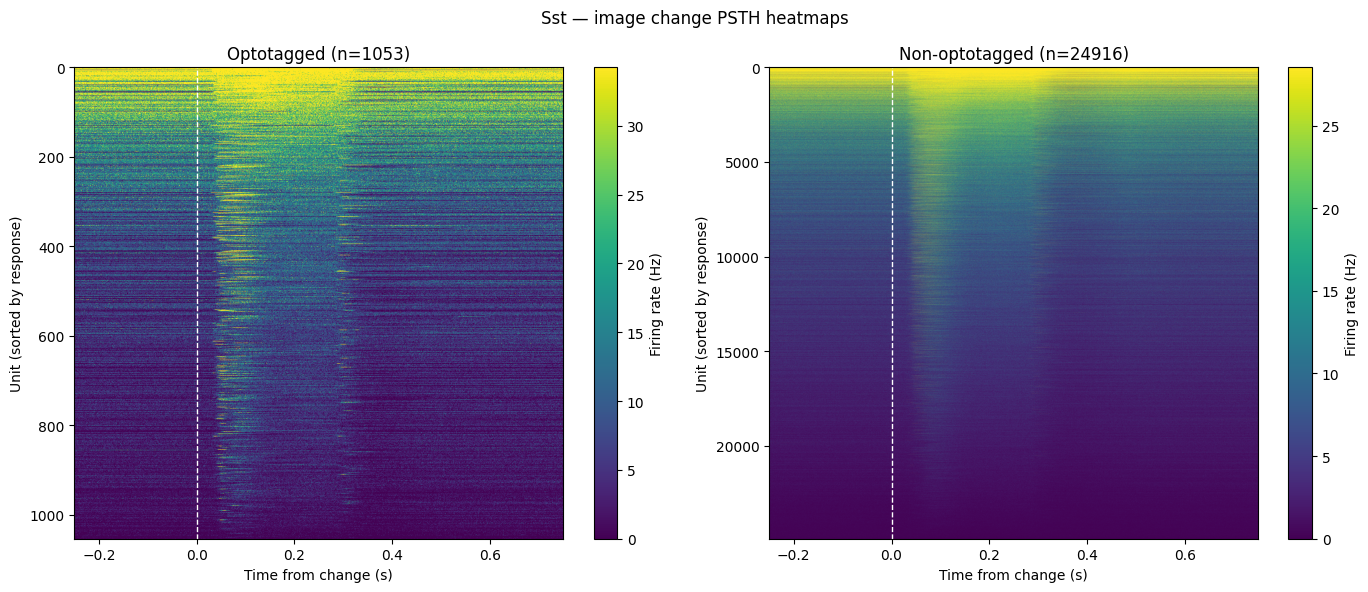

In [8]:
for gt, d in derived.items():
    fig = plot_psth_heatmaps(
        d["psth_opto"], d["psth_non_opto"], d["time_bins"],
        suptitle=f'{gt} — image change PSTH heatmaps',
        time_range=(-0.25, 0.75),
    )

---
### Region Distribution Analysis

Loads saved results for **all genotypes** (Vip + Sst) to characterize the labeled neurons across the dataset.

- **Slide 1** — How many Vip+ / Sst+ neurons do we have in each region? (absolute counts, all Novel sessions)
- **Slide 2** — Within each genotype's own sessions, how dense are the labeled neurons per region?

In [9]:
genotype_meta = {gt: d["meta_all"] for gt, d in derived.items()}

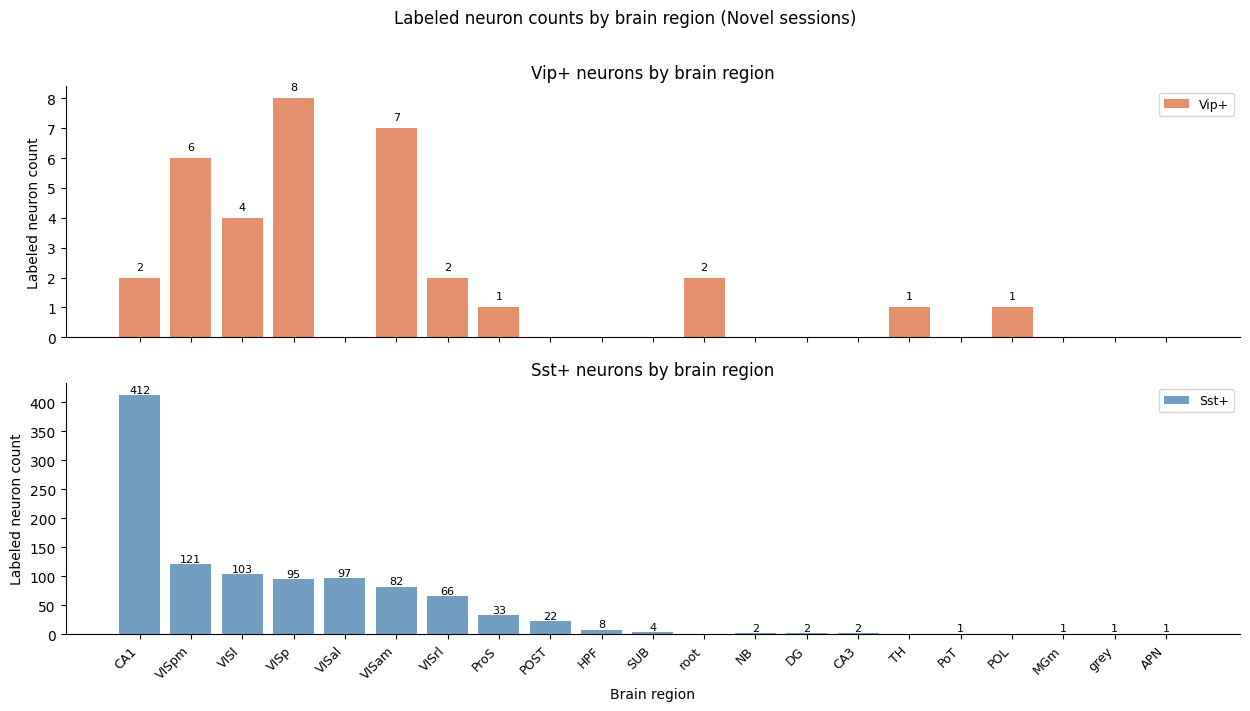

In [10]:
# Slide 1 — Absolute labeled neuron counts per region (separate panel per genotype)
# min_labeled=3: only show regions with at least 3 labeled cells total across both types
fig = plot_labeled_cells_by_region(genotype_meta, min_labeled=1)

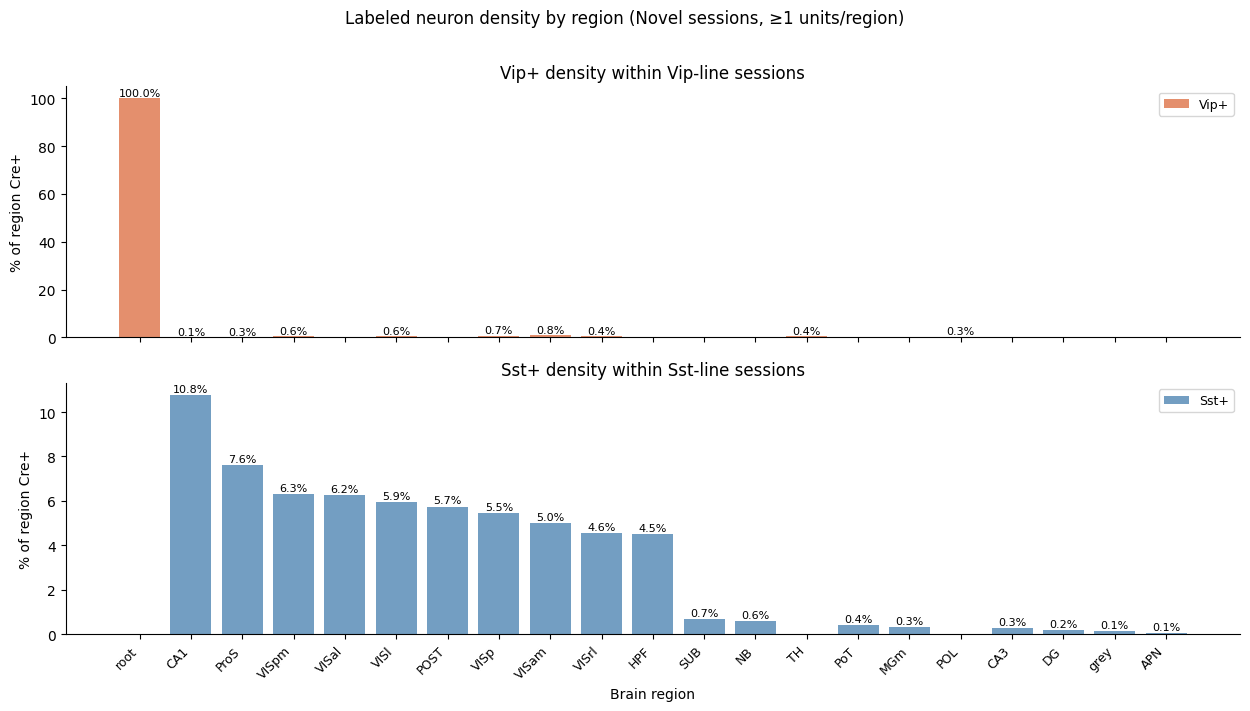

In [11]:
# Slide 2 — Labeled neuron density per region, within each genotype's own sessions
# min_units=50: need at least 50 units in a region to compute a meaningful fraction
# min_labeled=3: drop regions with only 1-2 stray labeled cells
fig = plot_cre_density_by_region(genotype_meta, min_units=1, min_labeled=1)